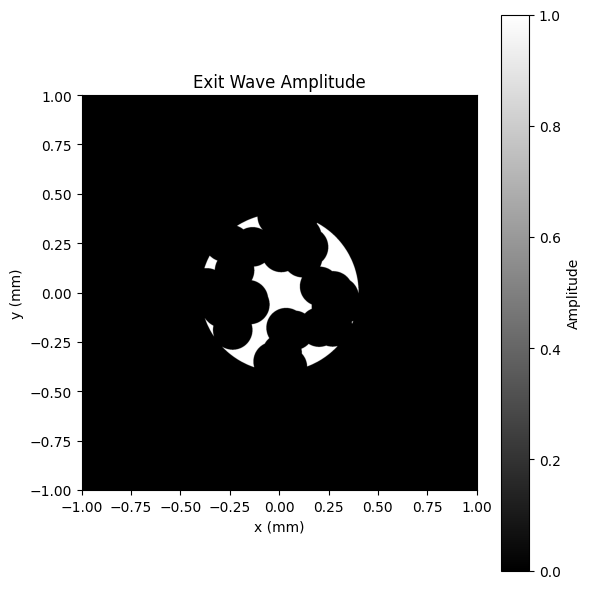

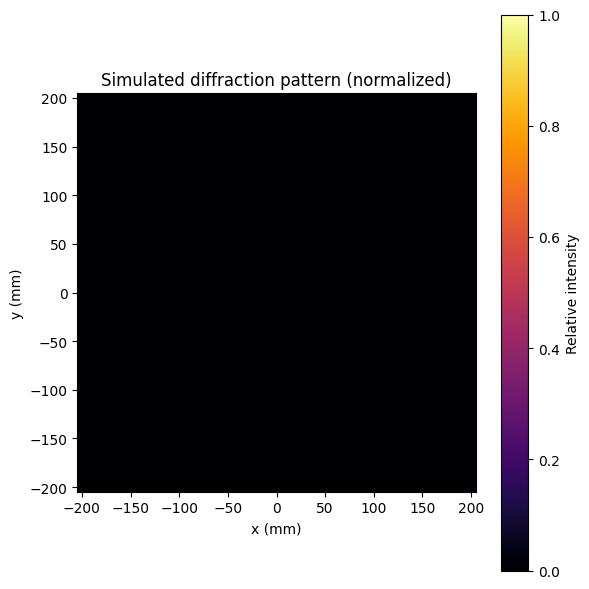

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

@dataclass
class Simulation:
    energy_keV: float = 50.0
    z: float = 0.0004                     # propagation [m]
    beam_size: float = 2e-3            # sample plane size [m]
    tube_diameter: float = 0.8e-3      # tube diameter [m]
    sphere_diameter: float = 200e-6    # sphere diameter [m]
    n_spheres: int = 30
    sample_N: int = 2048               # sample grid
    det_N: int = 2048                  # detector grid
    det_pixel: float = 200e-6          # detector pixel [m]

    wavelength: float = field(init=False)
    dx: float = field(init=False)
    tube_radius: float = field(init=False)
    sphere_radius: float = field(init=False)

    def __post_init__(self):
        self.wavelength = 1239.841984e-9 / (self.energy_keV * 1e3)
        self.dx = self.beam_size / self.sample_N
        self.tube_radius = self.tube_diameter / 2
        self.sphere_radius = self.sphere_diameter / 2

def angular_spectrum_method(u0: np.ndarray, wavelength: float, z: float, dx: float):
    k = 2 * np.pi / wavelength
    Ny, Nx = u0.shape
    U0 = np.fft.fft2(u0)
    U0s = np.fft.fftshift(U0)

    fx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))
    fy = np.fft.fftshift(np.fft.fftfreq(Ny, d=dx))
    FX, FY = np.meshgrid(fx, fy)

    arg = k**2 - (2*np.pi*FX)**2 - (2*np.pi*FY)**2
    H = np.exp(1j * z * np.sqrt(np.clip(arg, 0, None)))

    Uz = np.fft.ifft2(np.fft.ifftshift(U0s * H))
    return Uz

def build_exit_wave(sim: Simulation):
    N, dx = sim.sample_N, sim.dx
    x = (np.arange(N) - N/2) * dx
    X, Y = np.meshgrid(x, x)
    u0 = np.ones((N, N), dtype=complex)
    u0[(X**2 + Y**2) > sim.tube_radius**2] = 0

    rng = np.random.default_rng(1)
    centers = []
    while len(centers) < sim.n_spheres:
        cx, cy = rng.uniform(-sim.tube_radius, sim.tube_radius, size=2)
        if cx**2 + cy**2 <= sim.tube_radius**2:
            centers.append((cx, cy))

    for cx, cy in centers:
        mask = (X - cx)**2 + (Y - cy)**2 <= sim.sphere_radius**2
        u0[mask] = 0

    return u0

def remap_to_detector(I: np.ndarray, sim: Simulation):
    N, dx = sim.sample_N, sim.dx
    λ, z = sim.wavelength, sim.z
    det_N, det_dx = sim.det_N, sim.det_pixel

    dx_ff = λ * z / (N * dx)
    # detector coords in meters
    coords = (np.arange(det_N) - det_N/2) * det_dx
    sim_coords = coords / dx_ff + N/2

    X_idx, Y_idx = np.meshgrid(sim_coords, sim_coords)
    Xi = np.round(X_idx).astype(int)
    Yi = np.round(Y_idx).astype(int)

    I_det = np.zeros((det_N, det_N), dtype=I.dtype)
    valid = (Xi >= 0) & (Xi < N) & (Yi >= 0) & (Yi < N)
    I_det[valid] = I[Yi[valid], Xi[valid]]

    max_val = I_det.max()
    if max_val > 0:
        I_det /= max_val
    return I_det

def plot_exit_wave(u0: np.ndarray, sim: Simulation):
    """
    Plots the amplitude of the exit wave u0.
    """
    N, dx = sim.sample_N, sim.dx
    extent = np.array([-N/2, N/2, -N/2, N/2]) * dx * 1e3  # mm
    plt.figure(figsize=(6,6))
    plt.imshow(np.abs(u0), extent=extent, cmap='gray', origin='lower')
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.title('Exit Wave Amplitude')
    plt.colorbar(label='Amplitude')
    plt.tight_layout()
    plt.show()

def main():
    sim = Simulation()
    u0 = build_exit_wave(sim)
    plot_exit_wave(u0, sim)  # Plot the exit wave
    uz = angular_spectrum_method(u0, sim.wavelength, sim.z, sim.dx)
    I = np.abs(uz)**2
    I_det = remap_to_detector(I, sim)
    plot_pattern(I_det, sim)

if __name__ == "__main__":
    main()
